# Day 4 Laboratory Exercise: Reading A Discharge Summary

This morning's walkthrough took these 200 discharge summaries apart. It showed
that the median one needs 968 tokens and that the model accepts 510, that a
pre-trained model's guesses tell you what it was trained on, that a training
loop is a loss and a gradient and a step, and that a falling loss says nothing
about a document the model has not seen.

It also asked a question the corpus could not answer, and the coded diagnoses
turned out not to be recoverable from the prose at all.

This afternoon you ask a question the corpus can answer. Every one of these
admissions ended somehow, and the doctor who wrote the summary wrote down how.
So the question is whether a model can read a discharge summary and tell you
whether the patient died.

That is extraction rather than prediction, and the distinction matters. You are
not asking a model to foresee a death. You are asking whether it can find a fact
that is already written down, which is exactly what the day's project means by
extracting statistics from text.

The obvious way to do it fails, and it fails in a way that looks like success.

## How To Work Through This

There are eight tasks. Each states a goal, gives you a cell marked
`# YOUR CODE HERE` naming the variables the check expects, and follows it with a
check cell that either confirms your answer or tells you what it wanted.

Task 1 asks you to write down two numbers and then set them aside. Do set them
aside. You will need them again at Task 7, and the point of the afternoon
depends on your having stopped thinking about them in between.

Tasks 5 and 8 each train a transformer three times. On a graphics processor that
is under a minute each and on a processor about three, so start the cell and read
ahead while it runs.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
import re

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers.utils import logging as hf_logging

DATA_DIR = Path.cwd().parent / "data"

RANDOM_STATE = 42

MODEL = "distilbert/distilbert-base-uncased"
REVISION = "12040accade4e8a0f71eabdb258fecc2e7e948be"

hf_logging.disable_progress_bar()
hf_logging.set_verbosity_error()
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 110)


def check(condition, success, failure):
    """Report whether a task was completed correctly."""
    print(success if condition else failure)


def pick_device():
    """Use a GPU when the image provides one, and fall back sensibly."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = pick_device()

summaries = pd.read_csv(DATA_DIR / "discharge_summaries.csv")

# Tasks 1 and 7 both count tokens, so the tokeniser is made once here.
tokenizer = AutoTokenizer.from_pretrained(MODEL, revision=REVISION)

print("Documents:", len(summaries))
print("PyTorch:", torch.__version__, "| training on:", DEVICE)

Documents: 200
PyTorch: 2.11.0 | training on: mps


## The Tools You Are Given

The next cell holds the fine-tuning machinery for Tasks 5 and 8. Read it, run
it, and then leave it alone. Nothing in this laboratory exercise asks you to
change it, and both tasks that use it differ from each other by one argument.

Two things in it are worth noticing now.

`tokenise` takes a `truncation_side`. The walkthrough showed what that argument
does to a sequence of eight words. Here it decides what happens to a document of
nine hundred tokens.

`fine_tune` trains the same model three times, once per fold, and returns the
mean F1 on deaths, the mean accuracy, and the predictions and labels pooled
across the three held out sets. The pooled predictions are there because Task 6
needs to count something in them.

In [2]:
FOLDS = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
EPOCHS = 3
BATCH_SIZE = 8


def tokenise(texts, truncation_side="right", max_length=512):
    """Encode every document, keeping one end when it does not fit."""
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL, revision=REVISION, truncation_side=truncation_side)
    return tokenizer(list(texts), truncation=True, max_length=max_length,
                     padding="max_length", return_tensors="pt")


def fine_tune(encoded, target, verbose=True):
    """Fine-tune the model once per fold and score the held out documents.

    Returns the mean F1 on the positive class, the mean accuracy, and the
    pooled held out predictions and labels.
    """
    labels = torch.tensor(target)
    scores, accuracies, pooled_pred, pooled_true = [], [], [], []

    for number, (train, test) in enumerate(FOLDS.split(target, target), 1):
        torch.manual_seed(RANDOM_STATE)
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL, revision=REVISION, num_labels=2).to(DEVICE)
        optimiser = torch.optim.AdamW(model.parameters(), lr=2e-5)
        generator = torch.Generator().manual_seed(RANDOM_STATE)

        model.train()
        for epoch in range(EPOCHS):
            order = train[torch.randperm(len(train),
                                         generator=generator).numpy()]
            for start in range(0, len(order), BATCH_SIZE):
                batch = order[start:start + BATCH_SIZE]
                optimiser.zero_grad()
                model(input_ids=encoded["input_ids"][batch].to(DEVICE),
                      attention_mask=encoded["attention_mask"][batch].to(DEVICE),
                      labels=labels[batch].to(DEVICE)).loss.backward()
                optimiser.step()

        model.eval()
        chunks = []
        with torch.no_grad():
            for start in range(0, len(test), 16):
                batch = test[start:start + 16]
                logits = model(
                    input_ids=encoded["input_ids"][batch].to(DEVICE),
                    attention_mask=encoded["attention_mask"][batch].to(DEVICE),
                ).logits
                chunks.append(logits.float().argmax(1).cpu().numpy())
        predicted = np.concatenate(chunks)

        scores.append(f1_score(target[test], predicted, zero_division=0))
        accuracies.append(accuracy_score(target[test], predicted))
        pooled_pred.append(predicted)
        pooled_true.append(target[test])
        if verbose:
            print(f"  fold {number}: f1 {scores[-1]:.3f}  "
                  f"accuracy {accuracies[-1]:.3f}")
        del model

    return (float(np.mean(scores)), float(np.mean(accuracies)),
            np.concatenate(pooled_pred), np.concatenate(pooled_true))


def cross_validate_texts(model, texts, target):
    """Fit a scikit-learn model on each fold and return mean f1 and accuracy."""
    scores, accuracies = [], []
    for train, test in FOLDS.split(texts, target):
        fitted = model.fit(texts[train], target[train])
        predicted = fitted.predict(texts[test])
        scores.append(f1_score(target[test], predicted, zero_division=0))
        accuracies.append(accuracy_score(target[test], predicted))
    return float(np.mean(scores)), float(np.mean(accuracies))


print("Fine-tuning machinery ready.")

Fine-tuning machinery ready.


## Task 1: Measure The Documents Against The Model

Before anything else, find out how much of each document the model will accept.
The walkthrough did this for the English summaries and you are going to need the
numbers yourself.

Build a tokeniser, count the tokens in every English summary, and store three
things:

- `median_tokens`, the median number of tokens per document,
- `n_too_long`, how many of the 200 documents need more than 510 tokens, and
- `median_kept`, the median fraction of a document that survives a 512 token
  limit, which is `min(tokens, 510) / tokens` for each document.

A `tokenizer` is already built for you in the first cell, and
`tokenizer.tokenize(text)` gives you the pieces for one document.

In [3]:
token_counts = summaries["summary_en"].apply(
    lambda t: len(tokenizer.tokenize(t)))

median_tokens = float(token_counts.median())
n_too_long = int((token_counts > 510).sum())
median_kept = float((np.minimum(token_counts, 510) / token_counts).median())

print(f"median tokens per document: {median_tokens:.0f}")
print(f"documents needing more than 510 tokens: {n_too_long} of {len(summaries)}")
print(f"median fraction of a document that fits: {median_kept:.2f}")

median tokens per document: 968
documents needing more than 510 tokens: 177 of 200
median fraction of a document that fits: 0.53


In [4]:
check(
    "median_tokens" in dir() and "n_too_long" in dir()
    and "median_kept" in dir()
    and abs(median_tokens - 968) < 5
    and n_too_long == 177
    and abs(median_kept - 0.53) < 0.02,
    "Task 1 complete. The median document needs 968 tokens, 177 of the 200 do "
    "not fit, and a 512 token limit keeps about 53 percent of a typical one. "
    "Write those down and then set them aside.",
    "Not right yet. Expected median_tokens near 968, n_too_long to be 177, and "
    "median_kept near 0.53.",
)

Task 1 complete. The median document needs 968 tokens, 177 of the 200 do not fit, and a 512 token limit keeps about 53 percent of a typical one. Write those down and then set them aside.


### Set Those Numbers Aside

Roughly half of a typical document cannot reach the model. Nothing will warn
you about it and nothing you do below will fail because of it.

Write the three numbers down, and then stop thinking about them. The next five
tasks are about a different question, and Task 7 will tell you when to come
back.

## Task 2: Work Out What The Outcome Column Says

The question is whether a patient died, so you need a column saying whether a
patient died. Look at what you have.

`outcome_en` holds seven distinct strings for a two-valued fact, and some of
them contain braces. `length_of_stay` is mostly numbers with a few oddities in
it. Neither the braces nor the oddities are a loading error.

Work out what the notation means before you rely on it. `data/SOURCES.md` names
the paper that published this dataset, and the answer is in there. You can also
work it out from the data, which is the more interesting route: compare a braced
value against what the summary text says about the same admission.

Then build the target:

- `died`, a numpy array of 200 zeros and ones, where one means the patient died,
- `n_deaths`, how many died, and
- `disagreement`, the `record_id` of the single admission whose outcome column
  contains both possibilities.

Treat a braced value as the one to believe.

In [5]:
# A brace holds the value the reviewing physician substituted after reading the
# text, so a mention of death anywhere in the field means the patient died.
died = summaries["outcome_en"].str.contains(
    "death", case=False, na=False).to_numpy().astype(int)
n_deaths = int(died.sum())

both = summaries["outcome_en"].str.contains("alive", case=False) & \
    summaries["outcome_en"].str.contains("death", case=False)
disagreement = int(summaries.loc[both, "record_id"].iloc[0])

print(summaries["outcome_en"].value_counts().to_string())
print(f"\ndeaths: {n_deaths} of {len(summaries)} ({died.mean():.1%})")
print(f"the admission recorded both ways: record {disagreement}")
print("\nthe last 200 characters of that summary:")
print(summaries.loc[summaries["record_id"] == disagreement,
                    "summary_en"].iloc[0][-200:])

outcome_en
alive                 102
death                  50
alive {transfer}       25
{death}                11
{alive}                 8
{alive} {transfer}      3
alive {death}           1

deaths: 62 of 200 (31.0%)
the admission recorded both ways: record 53

the last 200 characters of that summary:
da tropicalis 07/31: candida tropicalis. tracheostomy on 07/28, massive bleeding on 07/30, assessed by head and neck surgery, compressive dressing applied. death. evolves with refractory septic shock.


In [6]:
check(
    "died" in dir() and "n_deaths" in dir() and "disagreement" in dir()
    and len(died) == 200
    and n_deaths == 62
    and disagreement == 53,
    "Task 2 complete. 62 of the 200 patients died, and record 53 is the one "
    "whose outcome column says both. Read the end of its summary before you "
    "move on.",
    "Not right yet. Expected `died` to have 200 entries, n_deaths to be 62, and "
    "disagreement to be 53.",
)

Task 2 complete. 62 of the 200 patients died, and record 53 is the one whose outcome column says both. Read the end of its summary before you move on.


### Record 53

Its outcome column reads `alive {death}`, and its summary ends with the
sentence "death. evolves with refractory septic shock."

The hospital's database says the patient survived. The document says the patient
did not, and a physician reading the document corrected the database. That is
what a brace marks throughout this file.

Keep that in view for the rest of the afternoon. Extracting facts from clinical
text is not a workaround for when the database is unavailable. Here it is the
only place the correct value was written down.

## Task 3: Take A Number Out Of The Text

The other thing the agenda asks for is a statistic pulled out of the prose, so
pull one out. Every summary opens with an administrative preamble, and many of
them state the length of the admission in it, in a form like `stay: 06 d`.

Extract it and compare it against the structured column.

- `stated`, the number of summaries whose English text states a stay in days or
  hours,
- `comparable`, the number where the text states a stay in **days** and
  `length_of_stay` holds a plain number, so the handful of summaries measured
  in hours and the rows whose column is annotated both drop out, and
- `off_by_one`, how many of those `comparable` rows have a column value exactly
  one greater than the text value.

The pattern `r"stay:\s*(\d+)\s*(h|d)\b"` will find the field. Use
`re.search` on each summary.

In [7]:
PATTERN = re.compile(r"stay:\s*(\d+)\s*(h|d)\b", re.IGNORECASE)

rows = []
for text, column in zip(summaries["summary_en"],
                        summaries["length_of_stay"].astype(str)):
    match = PATTERN.search(text)
    if match is None:
        continue
    days = int(match.group(1)) if match.group(2).lower() == "d" else None
    recorded = int(column) if re.fullmatch(r"\d+", column) else None
    rows.append((days, recorded))

stated = len(rows)
pairs = [(d, r) for d, r in rows if d is not None and r is not None]
comparable = len(pairs)
off_by_one = sum(1 for d, r in pairs if r - d == 1)

print(f"summaries stating a stay: {stated}")
print(f"of those, comparable against the column: {comparable}")
print(f"  column equals the text:        {sum(1 for d, r in pairs if d == r)}")
print(f"  column is one greater:         {off_by_one}")
print(f"  anything else:                 "
      f"{comparable - off_by_one - sum(1 for d, r in pairs if d == r)}")

summaries stating a stay: 109
of those, comparable against the column: 96
  column equals the text:        49
  column is one greater:         47
  anything else:                 0


In [8]:
check(
    "stated" in dir() and "comparable" in dir() and "off_by_one" in dir()
    and stated == 109
    and comparable == 96
    and off_by_one == 47,
    "Task 3 complete. 109 summaries state a stay, 96 of those state it in days "
    "against a plain number in the column, and the two agree exactly 49 times "
    "and differ by one day the other 47. Nothing differs by more than a day.",
    "Not right yet. Expected stated to be 109, comparable to be 96, and "
    "off_by_one to be 47. Count only the summaries that state the stay in days "
    "and whose length_of_stay is a plain number.",
)

Task 3 complete. 109 summaries state a stay, 96 of those state it in days against a plain number in the column, and the two agree exactly 49 times and differ by one day the other 47. Nothing differs by more than a day.


### Two Sources, One Day Apart

Of the 96 admissions where both sources give a figure in days, 49 agree exactly
and 47 have a column value one larger. Nothing differs by more than a day. That
is a counting convention rather than an error: one source counts the nights and
the other counts the days, including both the day of admission and the day of
discharge.

This is the ordinary situation with clinical text. The document and the database
mostly agree, they disagree in a way that follows a rule, and finding the rule is
the work. Record 53 was the case where the rule did not apply and the document
was simply right.

## Task 4: Build The Baseline First

You now have a target. Before reaching for a transformer, get a number from the
simplest thing that could possibly work, so that there is something to compare
against later. The walkthrough spent its last ten minutes on why this matters.

Build a scikit-learn pipeline of `TfidfVectorizer` and `LogisticRegression`,
score it with `cross_validate_texts`, and store the mean F1 on deaths in
`tfidf_f1` and the mean accuracy in `tfidf_accuracy`.

Use `make_pipeline`, pass `class_weight="balanced"` to the logistic regression
because the classes are uneven, and pass
`summaries["summary_en"].to_numpy()` as the texts.

Note that this method reads the whole document. It has no length limit at all.

In [9]:
english = summaries["summary_en"].to_numpy()

baseline = make_pipeline(
    TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2)),
    LogisticRegression(max_iter=2000, class_weight="balanced",
                       random_state=RANDOM_STATE),
)

tfidf_f1, tfidf_accuracy = cross_validate_texts(baseline, english, died)

print(f"counting words: f1 {tfidf_f1:.3f}  accuracy {tfidf_accuracy:.3f}")

counting words: f1 0.816  accuracy 0.905


In [10]:
check(
    "tfidf_f1" in dir() and "tfidf_accuracy" in dir()
    and abs(tfidf_f1 - 0.816) < 0.05
    and abs(tfidf_accuracy - 0.905) < 0.04,
    "Task 4 complete. Counting words scores an F1 of about 0.82 and an accuracy "
    "of about 0.90, reading the whole document. That is the number to beat.",
    "Not right yet. Expected tfidf_f1 near 0.816 and tfidf_accuracy near 0.905 "
    "from a TF-IDF and logistic regression pipeline scored with "
    "cross_validate_texts.",
)

Task 4 complete. Counting words scores an F1 of about 0.82 and an accuracy of about 0.90, reading the whole document. That is the number to beat.


A bag of words, with no idea what a word means and no idea what order the words
came in, gets nine documents in ten right.

That is your baseline. Now do it properly.

## Task 5: Fine-tune A Transformer On It

Now the method the day is named after. DistilBERT has sixty-six million
pre-trained weights and knows something about English, which a word count does
not.

Encode the English summaries with `tokenise`, fine-tune with `fine_tune`, and
store the mean F1 in `bert_f1` and the mean accuracy in `bert_accuracy`. Keep
the predictions and labels it returns, because the next task needs them.

Use `tokenise` exactly as it comes, with no arguments beyond the texts. That is
what every tutorial does, and it is what the defaults give you.

This trains three times. Expect under a minute on a graphics processor and about
three on a processor.

In [11]:
encoded = tokenise(summaries["summary_en"])

bert_f1, bert_accuracy, bert_predicted, bert_true = fine_tune(encoded, died)

print(f"\nDistilBERT: f1 {bert_f1:.3f}  accuracy {bert_accuracy:.3f}")
print(f"counting words: f1 {tfidf_f1:.3f}  accuracy {tfidf_accuracy:.3f}")

  fold 1: f1 0.000  accuracy 0.687


  fold 2: f1 0.000  accuracy 0.687


  fold 3: f1 0.000  accuracy 0.697

DistilBERT: f1 0.000  accuracy 0.690
counting words: f1 0.816  accuracy 0.905


In [12]:
check(
    "bert_f1" in dir() and "bert_accuracy" in dir()
    and "bert_predicted" in dir() and "bert_true" in dir()
    and bert_f1 < 0.3
    and bert_f1 < tfidf_f1 - 0.4,
    "Task 5 complete, and the result is worse than the bag of words by a wide "
    "margin. Do not fix it yet. Task 6 is about reading it correctly first.",
    "Not right yet. Expected `bert_f1` below 0.3 and at least 0.4 below "
    "tfidf_f1, from `tokenise` called with no arguments beyond the texts.",
)

Task 5 complete, and the result is worse than the bag of words by a wide margin. Do not fix it yet. Task 6 is about reading it correctly first.


### That Is Not What Was Supposed To Happen

Sixty-six million pre-trained weights, fine-tuned on this exact corpus for this
exact question, lost to counting words.

Before changing anything, read the two numbers you got rather than the one you
were hoping for.

## Task 6: Read The Accuracy Against A Baseline

The accuracy from Task 5 is around 0.69. On its own that sounds like a model
that has learned something imperfect.

Find out what it actually is.

- `base_rate`, the accuracy of always answering the commoner class, which is
  the larger of the two class proportions in `died`,
- `n_predicted_deaths`, how many of the pooled held out documents the model
  called a death, out of the 200 in `bert_predicted`, and
- `n_actual_deaths`, how many of them actually were, from `bert_true`.

In [13]:
base_rate = float(max(died.mean(), 1 - died.mean()))
n_predicted_deaths = int(bert_predicted.sum())
n_actual_deaths = int(bert_true.sum())

print(f"always answering the commoner class scores {base_rate:.3f}")
print(f"the fine-tuned model's accuracy was       {bert_accuracy:.3f}")
print()
print(f"deaths in the held out documents:  {n_actual_deaths}")
print(f"deaths the model predicted:        {n_predicted_deaths}")

always answering the commoner class scores 0.690
the fine-tuned model's accuracy was       0.690

deaths in the held out documents:  62
deaths the model predicted:        0


In [14]:
check(
    "base_rate" in dir() and "n_predicted_deaths" in dir()
    and "n_actual_deaths" in dir()
    and abs(base_rate - 0.69) < 0.005
    and n_actual_deaths == 62
    and n_predicted_deaths < 10
    and abs(bert_accuracy - base_rate) < 0.03,
    "Task 6 complete. The base rate is 0.69 and the model scored the base rate, "
    "because it found almost none of the 62 deaths. It did not learn something "
    "imperfect. It learned to say 'alive'.",
    "Not right yet. Expected base_rate near 0.69, n_actual_deaths to be 62, and "
    "n_predicted_deaths below 10.",
)

Task 6 complete. The base rate is 0.69 and the model scored the base rate, because it found almost none of the 62 deaths. It did not learn something imperfect. It learned to say 'alive'.


### The Accuracy Was The Base Rate

138 of the 200 patients survived, so a model that answers "alive" every time
scores 0.69. That is what this model scored, and it found almost none of the 62
deaths, which is why its F1 is near zero while its accuracy looks respectable.

So there was never a partly working model here. There was a model that learned
to answer with the commoner class, and an accuracy that concealed it.

That is the second time today a number has been read wrongly, and both times the
fix was the same: put a baseline next to it. In the walkthrough the baseline was
a bag of words that matched a fine-tuned transformer. Here it is a constant
answer that matches it.

Now, why? The transformer has strictly more information available than the bag
of words did. It knows what words mean and it knows what order they came in.
Something must be taking information away, and Task 7 is where you look for it.

## Task 7: Go Back To Task 1

Read your three numbers from Task 1 again, and then ask a question the
walkthrough deliberately did not answer: where in one of these documents does
the evidence of a death actually sit?

A discharge summary is written at the end of an admission and describes it in
the order it happened. So find out.

Among the documents where the patient died and the English text names it, using
the words `death`, `died`, or `deceased`, count:

- `visible_head`, how many have at least one of those words somewhere in
  their first 510 tokens, and
- `visible_tail`, how many have at least one of them somewhere in their last
  510 tokens.

A document shorter than 510 tokens counts in both, because all of it fits
either way.

Work in tokens rather than characters, because tokens are what the limit is
measured in. `tokenizer.tokenize(text)` gives you the list, and the words you
are looking for are single tokens in this vocabulary.

Then plot where the last mention falls, as a fraction of the way through each
document.

deaths whose text names the death: 61 of 62
  visible in the first 510 tokens: 19
  visible in the last 510 tokens:  61


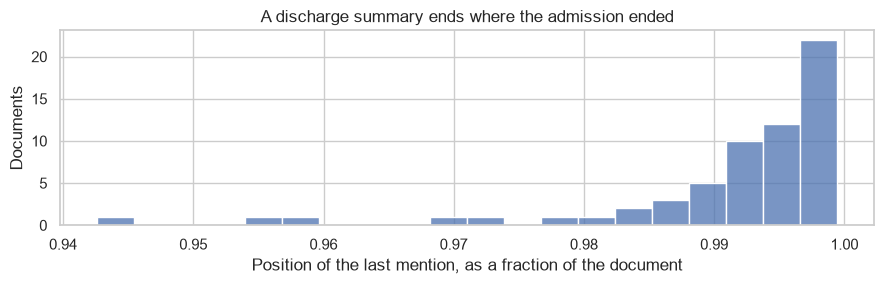

In [15]:
MENTIONS = {"death", "died", "deceased"}

positions, visible_head, visible_tail = [], 0, 0
for text, is_death in zip(summaries["summary_en"], died):
    if not is_death:
        continue
    pieces = tokenizer.tokenize(text)
    found = [i for i, piece in enumerate(pieces) if piece in MENTIONS]
    if not found:
        continue
    last = max(found)
    positions.append(last / len(pieces))
    if min(found) < 510:
        visible_head += 1
    if last >= len(pieces) - 510:
        visible_tail += 1

print(f"deaths whose text names the death: {len(positions)} of {int(died.sum())}")
print(f"  visible in the first 510 tokens: {visible_head}")
print(f"  visible in the last 510 tokens:  {visible_tail}")

fig, ax = plt.subplots(figsize=(9, 3))
sns.histplot(positions, bins=20, ax=ax)
ax.set_xlabel("Position of the last mention, as a fraction of the document")
ax.set_ylabel("Documents")
ax.set_title("A discharge summary ends where the admission ended")
plt.tight_layout()
plt.show()

In [16]:
check(
    "visible_head" in dir() and "visible_tail" in dir()
    and visible_head == 19
    and visible_tail == 61
    and visible_tail > visible_head * 3,
    "Task 7 complete. Reading from the front the model can see the answer in 19 "
    "of the 61 documents. Reading from the back it can see it in all 61. Now "
    "look again at what `tokenise` did for you in Task 5.",
    "Not right yet. Expected visible_head to be 19 and visible_tail to be 61, "
    "counted over the documents where the patient died and the text names it.",
)

Task 7 complete. Reading from the front the model can see the answer in 19 of the 61 documents. Reading from the back it can see it in all 61. Now look again at what `tokenise` did for you in Task 5.


### The Default Threw The Answer Away

61 documents out of 62 say in words that the patient died. 13 of those are
short enough to fit whole, so truncation costs them nothing. The other 48 have
to be cut, and only 6 of the 48 mention the death early enough to survive a cut
from the front. That is why the count from the front is 19 and the count from
the back is 61.

`truncation=True` keeps the beginning of a sequence, because `truncation_side`
defaults to `"right"`. The walkthrough showed that on eight words. On these
documents it means the model was handed the admission and the investigations,
and never reached the sentence saying how it ended.

So the model in Task 5 was not failing to learn. It was learning correctly from
evidence that had been removed before it ever saw it. Nothing raised an error,
nothing printed a warning, and the accuracy of 0.69 looked like a mediocre
result rather than a missing input.

## Task 8: Read The Other End

Fix it, and change nothing else.

Encode the same summaries keeping the end of each document instead of the
beginning, fine-tune with the same function on the same folds with the same
seed, and store the mean F1 in `tail_f1` and the mean accuracy in
`tail_accuracy`.

The only difference from Task 5 is one argument.

In [17]:
tail_encoded = tokenise(summaries["summary_en"], truncation_side="left")

tail_f1, tail_accuracy, tail_predicted, tail_true = fine_tune(tail_encoded, died)

print()
print(f"{'method':<34}{'f1':>8}{'accuracy':>11}")
print(f"{'always answering alive':<34}{0.0:>8.3f}{base_rate:>11.3f}")
print(f"{'counting words, whole document':<34}"
      f"{tfidf_f1:>8.3f}{tfidf_accuracy:>11.3f}")
print(f"{'DistilBERT, first 512 tokens':<34}"
      f"{bert_f1:>8.3f}{bert_accuracy:>11.3f}")
print(f"{'DistilBERT, last 512 tokens':<34}"
      f"{tail_f1:>8.3f}{tail_accuracy:>11.3f}")

  fold 1: f1 0.977  accuracy 0.985


  fold 2: f1 0.976  accuracy 0.985


  fold 3: f1 1.000  accuracy 1.000

method                                  f1   accuracy
always answering alive               0.000      0.690
counting words, whole document       0.816      0.905
DistilBERT, first 512 tokens         0.000      0.690
DistilBERT, last 512 tokens          0.984      0.990


In [18]:
check(
    "tail_f1" in dir() and "tail_accuracy" in dir()
    and tail_f1 > 0.85
    and tail_f1 > bert_f1 + 0.5
    and tail_accuracy > tfidf_accuracy,
    "Task 8 complete. One argument took the F1 from near zero to above 0.85, "
    "past the bag of words, without touching the model, the seed, the folds, "
    "the learning rate, or the number of epochs.",
    "Not right yet. Expected tail_f1 above 0.85 and at least 0.5 above bert_f1, "
    "from `tokenise(..., truncation_side='left')` and the same `fine_tune` "
    "call as Task 5.",
)

Task 8 complete. One argument took the F1 from near zero to above 0.85, past the bag of words, without touching the model, the seed, the folds, the learning rate, or the number of epochs.


### What Actually Happened

Nothing about the model changed. Same architecture, same sixty-six million
pre-trained weights, same seed, same three folds, same learning rate, same three
epochs, same 200 documents. One keyword argument moved, and the F1 went from
near zero to above 0.85.

Line the four numbers up and read them as a sequence.

Answering "alive" every time scores an accuracy of 0.69 and an F1 of zero. A bag
of words that reads the whole document scores about 0.90 and 0.82. A fine-tuned
transformer reading the first half of each document scores 0.69 and almost
nothing, which is to say it matched the constant answer. The same transformer
reading the last half of each document beats everything.

The ordering of those four is the whole afternoon. The most sophisticated method
came third, behind counting words and level with a constant, and it was not
because transformers are overrated. It was because it was reading the wrong half.

Three things are worth carrying out of this.

The first is that preprocessing decides what a model can possibly learn.
`truncation=True` is not a formatting detail, it is a choice about which half of
the evidence to discard, and the library makes that choice silently and
sensibly. Sensible defaults are chosen for short texts, and clinical documents
are not short.

The second is that a document has a shape. A discharge summary puts the outcome
at the end, a news article puts the conclusion at the top, a scientific paper
puts it in the abstract and again in the discussion, and a legal contract puts
the important part wherever it likes. Before truncating anything, ask where in
this kind of document the answer lives. There is no default that is right for
all of them.

The third is the habit, and it is the one that generalises furthest. Every
diagnostic step this afternoon came from putting a number next to another
number. Task 4's bag of words gave Task 5 something to be worse than. Task 6's
base rate turned an accuracy of 0.69 from a mediocre result into a model that
had learned nothing. Task 7's token positions turned that into a specific,
fixable cause. None of those came from looking harder at the transformer, and
none of them could have.

## Extensions

Work on these in any order if you have time left.

1. Task 8 keeps the last 510 tokens and throws away the beginning, which cannot
   be right either, since the diagnosis and the investigations are at the front.
   Split each document into two halves of 510 tokens, score each half on its
   own, and say what that tells you about where the information is.
2. There is a third option nobody used. Cut each document to its last 510
   tokens and cut it again to its first 510, then average the two models'
   predicted probabilities. Score it, and decide whether the extra complexity
   earned anything over Task 8.
3. A model with a longer limit would avoid the problem rather than working
   around it. Look up what `model_max_length` is for a model such as
   `allenai/longformer-base-4096` and work out from Task 1's token counts how
   many of these 200 documents it would take whole. Do not download it, because
   it is large and the session is short.
4. Search the text for the words `death`, `died`, and `deceased`, predict a
   death when any of them appears, and score that rule against the target with
   no model at all. Compare it against all four numbers in Task 8, then find the
   four documents it gets wrong and read them. Decide what the transformer is
   contributing over the search.
5. Repeat Task 8 on the Portuguese originals in `summary_pt`, keeping everything
   else the same. The tokeniser's vocabulary is English, so the same documents
   cost 2.56 tokens per word instead of 1.81 and fewer of them fit. Predict
   which way the score will move before you run it.
6. Every score in this notebook comes from three folds of 200 documents. Run
   Task 8 again with a different `random_state` in `FOLDS`, three times, and
   report the spread. Then decide which of this afternoon's conclusions survive
   that spread and which were never supported by it.

### Extension 1: Scoring Each Window Of A Document Separately

Task 8 replaced one arbitrary cut with another one. It reads the end of the
document and throws the beginning away, and the beginning is where the
diagnosis, the admission examination, and the investigations are. If the
outcome really is written at the end, then cutting the document into windows
and scoring each window on its own will say so, and it will also say what the
rest of the document is worth.

The median summary is 968 tokens, so three windows of 510 cover most of one.
The first window is what Task 5 saw, the last window is what Task 8 saw, and
the middle window is the part that no run so far has shown the model at all.

The cell below also builds the three tools the later extensions reuse. The
first encodes an arbitrary window of a document. The second is `fine_tune` with
the probability behind each decision kept, because averaging two models and
reading an area under the curve both need the probability rather than the
decision. The third scores such a probability the way `fine_tune` scores a
decision, so that every number below can be read against Tasks 5 and 8.

In [19]:
# An area under the curve reads a probability rather than a decision, so it
# needs an import the eight tasks had no use for.
from sklearn.metrics import roc_auc_score


def encode_window(texts, start, width=510):
    """Encode `width` tokens of each document, beginning at `start`.

    Truncation cuts from one end or the other, so a window out of the middle
    has to be cut by hand and turned back into text before it is encoded.
    """
    windows = [
        tokenizer.convert_tokens_to_string(
            tokenizer.tokenize(text)[start:start + width])
        for text in texts
    ]
    return tokenizer(windows, truncation=True, max_length=512,
                     padding="max_length", return_tensors="pt")


def fine_tune_probabilities(encoded, target, folds=FOLDS):
    """Fine-tune once per fold and keep the probability behind each decision.

    Tasks 5 and 8 needed a decision and `fine_tune` returns one. This returns
    the held out probability of death for every document, along with the fold
    that produced it, so that two runs can be averaged and scored together.
    """
    labels = torch.tensor(target)
    probability = np.zeros(len(target))
    fold_of = np.zeros(len(target), dtype=int)

    for number, (train, test) in enumerate(folds.split(target, target)):
        torch.manual_seed(RANDOM_STATE)
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL, revision=REVISION, num_labels=2).to(DEVICE)
        optimiser = torch.optim.AdamW(model.parameters(), lr=2e-5)
        generator = torch.Generator().manual_seed(RANDOM_STATE)

        model.train()
        for epoch in range(EPOCHS):
            order = train[torch.randperm(len(train),
                                         generator=generator).numpy()]
            for start in range(0, len(order), BATCH_SIZE):
                batch = order[start:start + BATCH_SIZE]
                optimiser.zero_grad()
                model(input_ids=encoded["input_ids"][batch].to(DEVICE),
                      attention_mask=encoded["attention_mask"][batch].to(DEVICE),
                      labels=labels[batch].to(DEVICE)).loss.backward()
                optimiser.step()

        model.eval()
        with torch.no_grad():
            for start in range(0, len(test), 16):
                batch = test[start:start + 16]
                logits = model(
                    input_ids=encoded["input_ids"][batch].to(DEVICE),
                    attention_mask=encoded["attention_mask"][batch].to(DEVICE),
                ).logits
                probability[batch] = torch.softmax(
                    logits.float(), -1)[:, 1].cpu().numpy()
        fold_of[test] = number
        del model

    return probability, fold_of


def score(probability, target, fold_of, threshold=0.5):
    """Score a probability the way `fine_tune` scores a decision.

    The F1 and the accuracy are means over the folds, so that they can be read
    against Tasks 5 and 8, and the area under the curve is taken once over the
    held out probabilities of all 200 documents.
    """
    predicted = (probability > threshold).astype(int)
    folds = np.unique(fold_of)
    f1s = [f1_score(target[fold_of == fold], predicted[fold_of == fold],
                    zero_division=0) for fold in folds]
    accuracies = [accuracy_score(target[fold_of == fold],
                                 predicted[fold_of == fold]) for fold in folds]
    return (float(np.mean(f1s)), float(np.mean(accuracies)),
            float(roc_auc_score(target, probability)))


head_probability, fold_of = fine_tune_probabilities(
    encode_window(english, 0), died)
middle_probability, _ = fine_tune_probabilities(
    encode_window(english, 510), died)
# The last window is what Task 8 encoded, so it is cut from the left instead.
tail_probability, _ = fine_tune_probabilities(tail_encoded, died)

print(f"{'window':<22}{'f1':>8}{'accuracy':>11}{'auc':>8}")
for label, probability in [("tokens 1 to 510", head_probability),
                           ("tokens 511 to 1020", middle_probability),
                           ("the last 510 tokens", tail_probability)]:
    window_f1, window_accuracy, window_auc = score(probability, died, fold_of)
    print(f"{label:<22}{window_f1:>8.3f}{window_accuracy:>11.3f}"
          f"{window_auc:>8.3f}")

window                      f1   accuracy     auc
tokens 1 to 510          0.000      0.690   0.571
tokens 511 to 1020       0.712      0.860   0.918
the last 510 tokens      0.984      0.990   1.000


The three windows are three different corpora as far as the model is
concerned.

The opening of a document is worth nothing. Tokens 1 to 510 reproduce Task 5
exactly, at an F1 of 0.000 and an area under the curve of 0.571, which is a
coin with a slight lean. The middle, which nothing in this notebook had shown
the model before, scores 0.712 and 0.918. The end reproduces Task 8, at 0.984
and 1.000.

So the answer is not one sentence sitting at the very bottom of the file. The
evidence accumulates as the admission goes on, and by the middle of a summary
there is already enough of it to find two deaths in three. Task 8 was therefore
not a trick that depends on the outcome being the last thing written. It was
reading the part of the document where the course of the admission is
described, and the further through that part you read, the more of it you have.

Notice also that the middle window ranks better than it decides, at an area
under the curve of 0.918 against an F1 of 0.712. A model can be good at putting
documents in order of risk and still be wrong about where to draw the line.
Extension 2 is that observation made expensive.

### Extension 2: Averaging The Two Models

Neither cut is defensible on its own, so the obvious repair is to make both and
let them vote. Each document is encoded twice, once from the front and once
from the back, a model is fine-tuned on each encoding, and the two predicted
probabilities are averaged before the threshold is applied. Extension 1 has
already trained both models, so the average costs nothing more to compute.

An ensemble of two views of the same document is a standard answer to a
document that does not fit, and it is worth finding out what it buys here.

method                                  f1   accuracy     auc
first 510 tokens                     0.000      0.690   0.571
last 510 tokens                      0.984      0.990   1.000
the two averaged                     0.528      0.830   0.993

On the 62 documents whose patient died, the median probability of death:
  the head model says 0.269
  the tail model says 0.714
  the average says    0.493

Deaths carried over the threshold of 0.5:
  by the tail model alone: 61 of 62
  by the average:          28 of 62


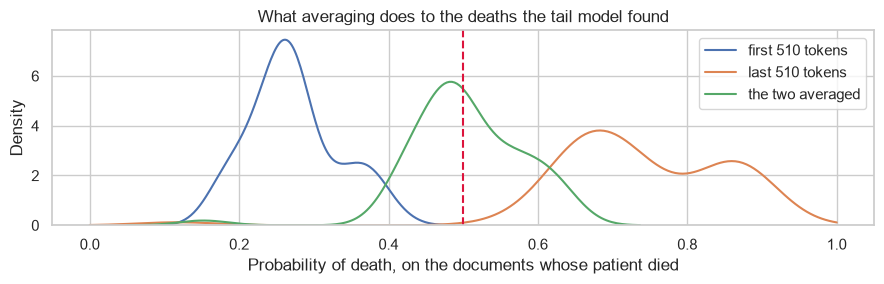

In [20]:
averaged = (head_probability + tail_probability) / 2

print(f"{'method':<34}{'f1':>8}{'accuracy':>11}{'auc':>8}")
for label, probability in [("first 510 tokens", head_probability),
                           ("last 510 tokens", tail_probability),
                           ("the two averaged", averaged)]:
    method_f1, method_accuracy, method_auc = score(probability, died, fold_of)
    print(f"{label:<34}{method_f1:>8.3f}{method_accuracy:>11.3f}"
          f"{method_auc:>8.3f}")

deaths = died == 1
print()
print("On the 62 documents whose patient died, the median probability of death:")
print(f"  the head model says {np.median(head_probability[deaths]):.3f}")
print(f"  the tail model says {np.median(tail_probability[deaths]):.3f}")
print(f"  the average says    {np.median(averaged[deaths]):.3f}")
print()
print("Deaths carried over the threshold of 0.5:")
print(f"  by the tail model alone: {int((tail_probability[deaths] > 0.5).sum())}"
      f" of {int(deaths.sum())}")
print(f"  by the average:          {int((averaged[deaths] > 0.5).sum())}"
      f" of {int(deaths.sum())}")

fig, ax = plt.subplots(figsize=(9, 3))
for probability, label in [(head_probability, "first 510 tokens"),
                           (tail_probability, "last 510 tokens"),
                           (averaged, "the two averaged")]:
    sns.kdeplot(x=probability[deaths], ax=ax, label=label, clip=(0, 1))
ax.axvline(0.5, color="crimson", linestyle="--")
ax.set_xlabel("Probability of death, on the documents whose patient died")
ax.set_title("What averaging does to the deaths the tail model found")
ax.legend()
plt.tight_layout()
plt.show()

The ensemble is worse than the tail model alone, and not by a little. The F1
falls from 0.984 to 0.528 and the accuracy from 0.990 to 0.830, which puts the
average of the two models below the bag of words that Task 4 built out of word
counts.

The area under the curve says where it went wrong, because it barely moves at
all, from 1.000 to about 0.99. The ranking is almost intact and the decisions
are ruined, which means the damage was done to the threshold rather than to the
model's ordering of the documents.

The printed medians show it happening. On the 62 documents whose patient died,
the tail model's probability of death has a median of 0.714 and the head
model's has a median of 0.269, so the average has a median of 0.493, which is
seven thousandths below the line that decides the answer. The tail model puts
61 of the 62 deaths above 0.5 and the average puts 28.

The lesson is not that ensembles do not work. It is that a model which is
confidently and consistently wrong is far more damaging in an average than one
which is merely noisy, because noise cancels and a bias does not. The head
model has no information, and averaging it in does not add a little value at
some cost, it subtracts a fixed amount from every document and drags the true
deaths back over the line. Had this been the first thing tried, the conclusion
would have been that a transformer cannot read a discharge summary.

### Extension 3: A Model That Would Not Have To Cut Anything

Every fix so far chooses which half of a document to discard. A model built for
long documents does not have to choose, and Longformer is the usual example,
accepting several thousand tokens instead of 512.

Two numbers answer the question, and only one of them is where a reader would
look first. The tokeniser's `model_max_length` is a field in a configuration
file that a publisher can leave unset, and the position embeddings are the
limit the architecture actually imposes. Read both, then count how many of
these 200 documents fit under it.

The weights are 597 megabytes and are not needed for any of that. The
configuration file is 694 bytes and the tokeniser is 2.6 megabytes, so the
question can be settled for about half a percent of the download.

In [21]:
from transformers import AutoConfig

LONGFORMER = "allenai/longformer-base-4096"
LONGFORMER_REVISION = "301e6a42cb0d9976a6d6a26a079fef81c18aa895"

config = AutoConfig.from_pretrained(LONGFORMER, revision=LONGFORMER_REVISION)
long_tokenizer = AutoTokenizer.from_pretrained(LONGFORMER,
                                               revision=LONGFORMER_REVISION)

print(f"DistilBERT model_max_length:        {tokenizer.model_max_length}")
print(f"Longformer model_max_length:        {long_tokenizer.model_max_length}")
print(f"Longformer max_position_embeddings: {config.max_position_embeddings}")

# Two positions of every sequence go to the markers around it, in this model as
# in DistilBERT, so the document itself gets what is left.
LONG_LIMIT = config.max_position_embeddings - 2
print(f"so a document may be:               {LONG_LIMIT} tokens")
print()

print(f"{'documents':<14}{'tokeniser':<12}{'median':>8}{'longest':>9}"
      f"{'fit in 510':>12}{'fit in ' + str(LONG_LIMIT):>13}")
for column, language in [("summary_en", "English"),
                         ("summary_pt", "Portuguese")]:
    for encoder, name in [(tokenizer, "WordPiece"),
                          (long_tokenizer, "byte pair")]:
        counts = summaries[column].apply(
            lambda text: len(encoder.tokenize(text)))
        print(f"{language:<14}{name:<12}{counts.median():>8.0f}"
              f"{counts.max():>9}{int((counts <= 510).sum()):>12}"
              f"{int((counts <= LONG_LIMIT).sum()):>13}")

DistilBERT model_max_length:        512
Longformer model_max_length:        1000000000000000019884624838656
Longformer max_position_embeddings: 4098
so a document may be:               4096 tokens

documents     tokeniser     median  longest  fit in 510  fit in 4096
English       WordPiece        968     3331          23          200


English       byte pair        923     3218          24          200
Portuguese    WordPiece       1382     4396           5          199


Portuguese    byte pair       1440     4483           4          199


The field the question names does not answer it. Longformer's
`model_max_length` is 1000000000000000019884624838656, which is the sentinel
transformers uses when a tokeniser's configuration states no limit at all, and
a number that large is a missing value wearing a disguise. DistilBERT's states
512, which is why nothing in this notebook had to look any further.

`max_position_embeddings` is the limit that exists whether anybody writes it
down or not, because a position the model has no embedding for is a position it
cannot represent. Longformer has 4098 of them, two of which go to the markers
around the document, so a document may be 4096 tokens.

That is enough for this corpus twice over. All 200 English summaries fit whole,
the longest needing 3331 tokens against the 510 the afternoon was fighting
over, and 199 of the 200 Portuguese originals fit, the exception needing 4396.
Counted with Longformer's own byte pair tokeniser rather than DistilBERT's
WordPiece the numbers move a little and the answer does not, at 3218 and 4483
tokens for those two longest documents.

So the trap this afternoon fell into is a property of a 512 position limit
rather than a property of clinical text, and the durable answer to it is a
model built for long documents rather than a cleverer way of cutting them up.
Two cautions before anybody downloads one. It is 597 megabytes against
DistilBERT's 268 and it is slower to train, which on a corpus of 200 documents
buys very little over the one argument Task 8 changed. And it does not make the
question of where the answer sits go away, it only makes it unnecessary here.
The next corpus may be case notes running to forty thousand tokens, and then
the same afternoon happens again at a larger limit.

### Extension 4: Searching For The Word, With No Model At All

Somebody always asks this, and they are right to. The outcome is a word in the
text, so search for the word. The rule is that a document mentioning death,
died, or deceased belongs to a patient who died, and it fits nothing, so there
is no training set, no fold, and no seed.

That last point cuts both ways when the scores are compared. A rule that fits
nothing cannot overfit, and it also gets to be scored on the same 200 documents
that would be held out from anything else, so it is being flattered relative to
the cross-validated numbers beside it. Read the comparison with that in mind.

In [22]:
MENTION = r"\bdeath\b|\bdied\b|\bdeceased\b"

found = summaries["summary_en"].str.contains(
    MENTION, case=False, regex=True).to_numpy().astype(int)
search_f1 = f1_score(died, found)
search_accuracy = accuracy_score(died, found)

print(f"{'method':<34}{'f1':>8}{'accuracy':>11}")
print(f"{'always answering alive':<34}{0.0:>8.3f}{base_rate:>11.3f}")
print(f"{'counting words, whole document':<34}"
      f"{tfidf_f1:>8.3f}{tfidf_accuracy:>11.3f}")
print(f"{'DistilBERT, first 512 tokens':<34}"
      f"{bert_f1:>8.3f}{bert_accuracy:>11.3f}")
print(f"{'DistilBERT, last 512 tokens':<34}"
      f"{tail_f1:>8.3f}{tail_accuracy:>11.3f}")
print(f"{'searching for the word':<34}"
      f"{search_f1:>8.3f}{search_accuracy:>11.3f}")

print()
print(pd.crosstab(pd.Series(found, name="mentions one of the three words"),
                  pd.Series(died, name="died")).to_string())

wrong = np.flatnonzero(found != died)
print(f"\nwrong on {len(wrong)} of {len(died)}: records "
      f"{summaries.loc[wrong, 'record_id'].tolist()}")

for row in wrong:
    text = summaries.loc[row, "summary_en"]
    outcome = "died" if died[row] else "survived"
    print(f"\nrecord {summaries.loc[row, 'record_id']}, the patient {outcome}, "
          f"the rule said {'died' if found[row] else 'survived'}")
    hits = list(re.finditer(MENTION, text, flags=re.IGNORECASE))
    if hits:
        for hit in hits:
            print(f"  ...{text[max(0, hit.start() - 110):hit.end() + 110]}...")
    else:
        print(f"  the summary ends: ...{text[-220:]}")

method                                  f1   accuracy
always answering alive               0.000      0.690
counting words, whole document       0.816      0.905
DistilBERT, first 512 tokens         0.000      0.690
DistilBERT, last 512 tokens          0.984      0.990
searching for the word               0.968      0.980

died                               0   1
mentions one of the three words         
0                                135   1
1                                  3  61

wrong on 4 of 200: records [19, 85, 97, 104]

record 19, the patient survived, the rule said died
  ...omyopathy, probable alcoholic etiology, pericardial effusion to be clarified since 2015, mentions brother who died 1 year ago, at age 45, with diagnosis of pulmonary tuberculosis, previous discussion with probable etiology d...

record 85, the patient survived, the rule said died
  ...ic, tests on 03/23, reinforces with [person] the importance of finishing treatment and reinforces the risk of death invol

The search scores an F1 of 0.968 and an accuracy of 0.980, correct on 196 of
the 200 documents. It beats the bag of words at 0.816, it beats Task 5 by the
whole distance from nothing to almost everything, and it comes second to Task
8's 0.984 by about a point and a half of F1. A student who says that a regular
expression would have done is right, and should be told so.

The four it gets wrong are worth reading, because they are what the extra point
and a half is made of. Three are survivors whose summaries mention a death that
is not the patient's. Record 19 mentions a brother who died a year ago of
tuberculosis, record 97 records two deaths in the family history, and record 85
records a clinician warning the patient of the risk of death if the treatment
is not finished. The fourth, record 104, is a patient who died and whose
summary never uses any of the three words: it ends in the middle of a
description of failing ventilation, dialysis that could not be performed, and
thrombocytopenia, and a reader knows how that ended without the word being
written.

So what the transformer contributes is context. It has seen that a death in a
family history sits among ages and other diagnoses rather than among the
admission's own events, and it has seen what the end of a fatal admission
reads like when nobody writes the word down. That is worth two documents in
200 here, and the honest way to report it is as two documents in 200 rather
than as a difference between 0.968 and 0.984.

One caveat sits under the whole comparison. The transformer's 0.984 is a mean
over three held out folds and the search's 0.968 is scored on all 200 documents
at once, because a rule that fits nothing has nothing to hold out. The
comparison is therefore slightly generous to the search, which means the gap
between the two is if anything a little wider than the two numbers make it
look, and the right response is to say which number was measured how rather
than to pick whichever ordering suits the argument.

### Extension 5: The Same Fix On The Portuguese Originals

The summaries were written in Brazilian Portuguese and translated into English
by the authors, so `summary_pt` is the document the hospital actually produced.
Task 8 on that column changes one thing, which is the language, and a
prediction is worth making before the cell runs.

Two forces pull in opposite directions. DistilBERT's vocabulary was built from
English, so Portuguese costs more tokens per word and the same 510 tokens reach
back over less of the document. Against that, the word that names the outcome
may be a cleaner signal in the original than in the translation, since a
translator has synonyms available and a discharge summary has a house style.

The cell measures the score, the cost of the vocabulary in each language, and
how well a single word separates the two classes in each language.

In [23]:
portuguese = summaries["summary_pt"].to_numpy()
portuguese_encoded = tokenise(portuguese, truncation_side="left")

portuguese_probability, _ = fine_tune_probabilities(portuguese_encoded, died)
portuguese_f1, portuguese_accuracy, portuguese_auc = score(
    portuguese_probability, died, fold_of)
english_f1, english_accuracy, english_auc = score(
    tail_probability, died, fold_of)

print(f"{'last 510 tokens of':<22}{'f1':>8}{'accuracy':>11}{'auc':>8}")
print(f"{'the translation':<22}{english_f1:>8.3f}{english_accuracy:>11.3f}"
      f"{english_auc:>8.3f}")
print(f"{'the original':<22}{portuguese_f1:>8.3f}{portuguese_accuracy:>11.3f}"
      f"{portuguese_auc:>8.3f}")

print()
print(f"{'documents':<14}{'words':>9}{'tokens':>9}{'per word':>10}"
      f"{'over 510':>10}")
for column, language in [("summary_en", "English"),
                         ("summary_pt", "Portuguese")]:
    words = summaries[column].str.split().apply(len)
    tokens = summaries[column].apply(lambda text: len(tokenizer.tokenize(text)))
    print(f"{language:<14}{words.sum():>9}{tokens.sum():>9}"
          f"{tokens.sum() / words.sum():>10.2f}{int((tokens > 510).sum()):>10}")

print()
print("How well one word separates the two classes:")
# The corpus spells the Portuguese word both with and without its accent. The
# third pattern is the same search written with word boundaries, and it is
# there because whether a boundary holds in front of an accented letter depends
# on which regular expression engine pandas hands the search to.
for column, pattern, label in [
        ("summary_en", MENTION, "death, died, or deceased"),
        ("summary_pt", r"[oó]bito", "obito or óbito"),
        ("summary_pt", r"\bobito\b|\bóbito\b", "the same, with boundaries")]:
    hits = summaries[column].str.contains(
        pattern, case=False, regex=True).to_numpy().astype(int)
    print(f"  {label:<26} found in {int(hits[deaths].sum())} of "
          f"{int(deaths.sum())} deaths and "
          f"{int(hits[~deaths].sum())} of {int((~deaths).sum())} survivals")

last 510 tokens of          f1   accuracy     auc
the translation          0.984      0.990   1.000
the original             0.107      0.710   0.851

documents         words   tokens  per word  over 510
English          119742   216850      1.81       177


Portuguese       117755   301702      2.56       195

How well one word separates the two classes:
  death, died, or deceased   found in 61 of 62 deaths and 3 of 138 survivals
  obito or óbito             found in 62 of 62 deaths and 0 of 138 survivals
  the same, with boundaries  found in 24 of 62 deaths and 0 of 138 survivals


The score collapses, from an F1 of 0.984 on the translation to 0.107 on the
original, with the accuracy back down at 0.710 and near the base rate. Anybody
who predicted that the score would fall was right, and almost nobody predicts
that it falls this far.

The obvious explanation is the one the day has been about, and it is only half
the story. DistilBERT's vocabulary was built from English, so the same
documents cost 2.56 tokens per word here against 1.81 on the translation, and
195 of the 200 exceed the limit rather than 177. The last 510 tokens therefore
reach back over noticeably less of each document than they did in English.

The other half is that the evidence in the original is better rather than
worse. The word `óbito` appears, spelled with the accent or without it, in all
62 of the summaries whose patient died and in none of the 138 whose patient
survived, which makes it a cleaner indicator than English's death, died, or
deceased at 61 of 62 with three false positives. Every document still contains
the answer, stated in one unambiguous word, and the model scores 0.107.

So the failure is the model's representation of a language it was not trained
on rather than a shortage of information in the text. The area under the curve
of 0.851 is the shape of that failure: the model has learned something, enough
to put documents in a defensible order, and not enough for any threshold on
that order to be useful. The remedy is a model whose vocabulary and
pre-training match the language of the corpus, which is the same argument
Section 3 of the walkthrough made about clinical English with
Bio_ClinicalBERT, arriving here for a second time and from a different
direction.

One practical note that has nothing to do with models. Compare the last two
rows the cell printed, which are the same search written twice. Asking for a
word boundary in front of an accented letter is not portable, because pandas
hands `Series.str.contains` to Python's regular expression engine or to
pyarrow's depending on what is installed, and the two disagree about whether a
boundary exists there. On the machine these materials were prepared on, with
pyarrow present, `\bobito\b|\bóbito\b` finds 24 of the 62 deaths and the
same search without the boundaries finds all 62. If the two rows agree in your
environment, you have the other engine, and the pattern that depends on the
difference is still the one to avoid.

### Extension 6: How Much Of This Was The Split

Every number in this notebook came from three folds of 200 documents, which is
67 held out documents at a time, of which about 21 are deaths. A difference of
one document in a fold moves an F1 by more than a hundredth, so the question is
not whether the figures move but which of the afternoon's conclusions survive
the movement.

Repeating Task 8 under a different `random_state` changes which documents land
in which fold and changes nothing else. The encoding, the model, the seed
inside the training loop, and the number of epochs all stay where they were.

In [24]:
seed_f1s = [tail_f1]
print(f"{'fold seed':<12}{'f1':>8}{'accuracy':>11}{'auc':>8}")
print(f"{RANDOM_STATE:<12}{tail_f1:>8.3f}{tail_accuracy:>11.3f}"
      f"{english_auc:>8.3f}")

for seed in (7, 13, 2024):
    seeded_folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    seeded_probability, seeded_fold_of = fine_tune_probabilities(
        tail_encoded, died, folds=seeded_folds)
    seeded_f1, seeded_accuracy, seeded_auc = score(
        seeded_probability, died, seeded_fold_of)
    seed_f1s.append(seeded_f1)
    print(f"{seed:<12}{seeded_f1:>8.3f}{seeded_accuracy:>11.3f}"
          f"{seeded_auc:>8.3f}")

print()
print(f"four seeds: mean {np.mean(seed_f1s):.3f}, "
      f"standard deviation {np.std(seed_f1s):.3f}, "
      f"from {min(seed_f1s):.3f} to {max(seed_f1s):.3f}")
for label, comparison in [("Task 5's first 510 tokens", bert_f1),
                          ("Task 4's bag of words", tfidf_f1)]:
    beaten = sum(1 for f1 in seed_f1s if f1 > comparison)
    print(f"seeds beating {label} at {comparison:.3f}: "
          f"{beaten} of {len(seed_f1s)}")

fold seed         f1   accuracy     auc
42             0.984      0.990   1.000


7              0.787      0.915   0.994


13             0.967      0.980   0.998


2024           0.958      0.975   0.998

four seeds: mean 0.924, standard deviation 0.080, from 0.787 to 0.984
seeds beating Task 5's first 510 tokens at 0.000: 4 of 4
seeds beating Task 4's bag of words at 0.816: 3 of 4


Four seeds give F1 scores of 0.984, 0.787, 0.967, and 0.958, a mean of 0.924
with a standard deviation of 0.080. Nothing changed between those four runs
except which documents were held out together.

So the exact figure moves a great deal and the direction does not move at all,
and the afternoon's conclusions divide cleanly on that distinction.

The conclusion that survives is the one the afternoon was about. Every seed is
enormously above Task 5's 0.000, and the worst of them is above it by 0.787,
which no amount of resampling is going to reverse. `truncation_side` decided
whether this task was possible or impossible, and that gap is not a fold
effect.

The conclusion that does not survive is the ranking against the baseline. Three
seeds put the fine-tuned model above Task 4's 0.816 and one puts it below, so
the claim that reading the end of a document beats counting the words in all of
it is not supported by three folds of 200 documents. Nothing in Tasks 1 to 8
rests on that claim, which is worth checking rather than assuming: Task 4's
baseline was built to interpret Task 5's failure, and it did that job whichever
way this comparison falls.

Notice which number moved most. The accuracy stays between 0.915 and 0.990
while the F1 travels from 0.787 to 0.984, because the F1 is computed on the
deaths alone and each fold holds out about 21 of them, so a handful of documents
moves it by a tenth. When a small held out set is scored on a minority class,
the metric that matters is the one with the fewest cases behind it, and one
decimal place of it is noise.

The general habit is the one to leave with. A single split gives a number, and
a number without a spread beside it cannot tell you which of your conclusions
it supports. Rerunning under three more seeds costs three minutes here, and it
is the cheapest insurance in this notebook.

## What To Take Away

- A document is not a row, and the first thing to measure about one is whether
  the model can accept it. The median summary here needs 968 tokens and the
  model takes 510.
- `truncation=True` keeps the beginning. That is a decision about which evidence
  to discard, it is made silently, and no error or warning marks it.
- Ask where in a document the answer lives before cutting the document.
  Discharge summaries end with the outcome, and that is a property of the genre
  rather than of this dataset.
- An accuracy means nothing without the base rate beside it. 0.69 here was not a
  mediocre model, it was a model that answered "alive" every time.
- An F1 near zero beside a respectable accuracy is the signature of a model that
  has learned the commoner class. Print both.
- Fit the simplest thing first and keep its score. A bag of words beat a
  fine-tuned transformer, which was the evidence that something was wrong with
  the transformer's input rather than with the transformer.
- Braces in this dataset mark a physician overruling the database from the text.
  Record 53 is a patient the database recorded as discharged and the document
  recorded as dead.
- The most useful thing you can do to a number is put another number next to it.